In [22]:
from os import listdir, rename
from os.path import isfile, join, exists

In [29]:
def get_path(dataset, filter, imgs, split):
    return f"{dataset}{'_filter' if filter else ''}/{'images' if imgs else 'labels'}/{split}"

In [30]:
# read the labels text file, see how many people there are. 
# if there are more than 5 and less than 15, copy the label file and 
# the image to their corresponding coco_filter paths
# and append them at the end of <split>.txt file

# coco person labels: ['0']
# kitti person labels: ['3', '4']

def filter_dataset(dataset, splits, person_labels, extension='.jpg'):
    for current_split in splits:
#        current_split = "train2017"
        data_path = get_path(dataset, False, False, current_split)
        
        
        for f in listdir(data_path):
            file_path = join(data_path, f)
            if not isfile(file_path):
                continue
        
            people_count = 0
            people_labels = []
            # our people labels is 0
            with open(file_path) as _file:
                for line in _file.readlines():
                    label = line.split()[0]
                    if label in person_labels:
                        people_count += 1
                        people_labels.append(line)
        
            # if it's not within our range, skip entry
            if people_count < 5 or people_count > 15:
                continue
        
            filename_no_ext = f.split('.')[0]
        
            old_img_path = f"{get_path(dataset, False, True, current_split)}/{filename_no_ext}{extension}"
            if not exists(old_img_path):
                continue
            
            new_img_path = f"{get_path(dataset, True, True, current_split)}/{filename_no_ext}{extension}"
            rename(old_img_path, new_img_path)
        
            new_labels_path = f"{get_path(dataset, True, False, current_split)}/{filename_no_ext}.txt"
            with open(new_labels_path, "w") as text_file:
                text_file.write(''.join(people_labels))
        
    print("Filtering done")

In [32]:
filter_dataset("kitti", ['train', 'val'], ['3', '4'], extension='.png')

Filtering done


In [ ]:
import secrets                              # imports secure module.
secure_random = secrets.SystemRandom()      # creates a secure random object.
group_of_items = {'a', 'b', 'c', 'd', 'e'}  # a sequence or set will work here.
num_to_select = 2                           # set the number to select here.
list_of_random_items = secure_random.sample(group_of_items, num_to_select)
first_random_item = list_of_random_items[0]
second_random_item = list_of_random_items[1]

In [34]:
import secrets
secure_random = secrets.SystemRandom()

In [40]:
# Do a train/val split at 70/30

train_labels_path = get_path("crowdhuman", True, False, "train")
all_train_labels = listdir(train_labels_path)
validation_size = int(len(all_train_labels) * 0.3)

list_of_random_labels = secure_random.sample(all_train_labels, validation_size)

val_labels_path = get_path("crowdhuman", True, False, "val")
val_images_path = get_path("crowdhuman", True, True, "val")

train_images_path = get_path("crowdhuman", True, True, "train")
for item in list_of_random_labels:
    filename_no_ext = item.split('.')[0]

    old_img_path = f"{train_images_path}/{filename_no_ext}.jpg"
    new_img_path = f"{val_images_path}/{filename_no_ext}.jpg"
    rename(old_img_path, new_img_path)

    old_label_path = f"{train_labels_path}/{filename_no_ext}.txt"
    new_label_path = f"{val_labels_path}/{filename_no_ext}.txt"
    rename(old_label_path, new_label_path)

print('Moving done')

Moving done


In [47]:
def fix_file(filename):
    labels = []
    with open(filename) as _file:
        for line in _file.readlines():
            new_label = f"0{line[1:]}"
            labels.append(new_label)

    with open(filename, 'w') as _w_file:
        _w_file.write(''.join(labels))

In [53]:
# fix kitti labels

kitti_train_labels = get_path("kitti", True, False, "train")
kitti_val_labels = get_path("kitti", True, False, "val")

for train_file in listdir(kitti_train_labels):
    fix_file(f"{kitti_train_labels}/{train_file}")

for val_file in listdir(kitti_val_labels):
    fix_file(f"{kitti_val_labels}/{val_file}")

In [91]:
# count images in our custom dataset
# we start at 5 and go up to 15

def count_people(data_path):
    people_dict = {}
    for f in listdir(data_path):
        file_path = join(data_path, f)
        if not isfile(file_path):
            continue
    
        people_count = 0
        with open(file_path) as _file:
            for line in _file.readlines():
                label = line.split()[0]
                people_count += 1 if label == '0' else 0
        
        if people_count in people_dict:
            people_dict[people_count] += 1
        else:
            people_dict[people_count] = 1

    # return x, y
    return list(people_dict.keys()), list(people_dict.values())

In [57]:
import matplotlib.pyplot as plt

In [106]:
# draw graphs for each

def plot_people(labels_path, split, color):
    x, y = count_people(labels_path)
   
    plt.figure(figsize=(8,5))
    plt.bar(x, y, color=color)
    plt.xticks(range(5, 5+len(x)))
    plt.xlabel("Number of persons in image")
    plt.ylabel("Number of images")
    plt.title(f"Combined Dataset {split} Images - Person Distribution ({len(listdir(labels_path))} samples)")
    plt.show()

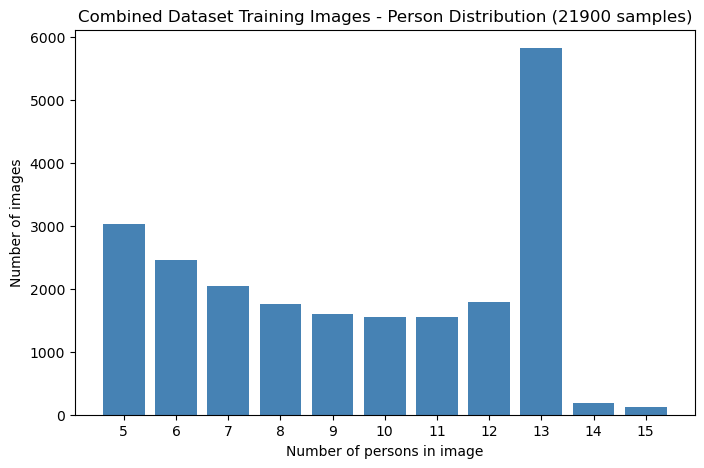

In [107]:
train_path = get_path("custom", False, False, "train")
plot_people(train_path, "Training", 'steelblue')

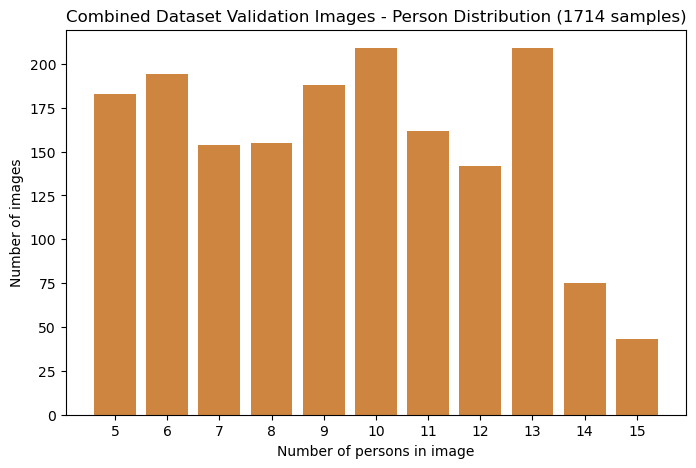

In [108]:
val_path = get_path("custom", False, False, "val")
plot_people(val_path, "Validation", "peru")

In [93]:
# quickly sort all the indices
def sort_split(x, y):
    tmp_x, tmp_y = x.copy(), y.copy()
    for i in range(5, 16):
        idx = x.index(i)
        tmp_x[i-5] = x[idx]
        tmp_y[i-5] = y[idx]
    #self.x, self.y = tmp_x, tmp_y
    return tmp_x, tmp_y

[5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15] [3032, 2447, 2047, 1752, 1599, 1558, 1546, 1793, 5817, 183, 126]
[5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15] [183, 194, 154, 155, 188, 209, 162, 142, 209, 75, 43]


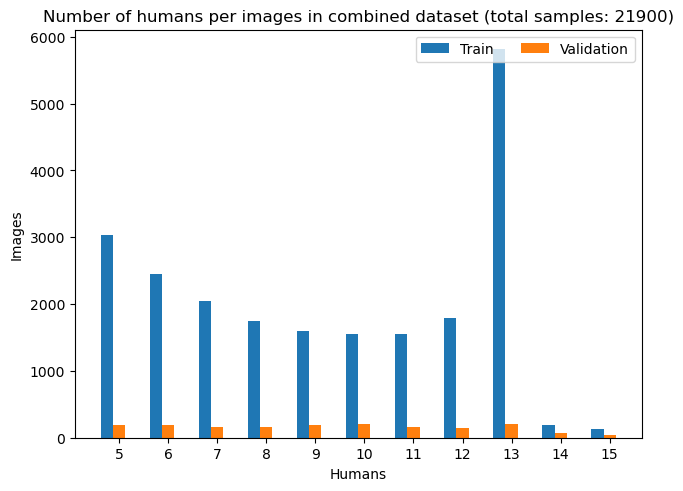

In [94]:
import matplotlib.pyplot as plt
import numpy as np

train_path = get_path("custom", False, False, "train")
x_train, y_train = sort_split(*count_people(train_path))

val_path = get_path("custom", False, False, "val")
x_val, y_val = sort_split(*count_people(val_path))

print(x_train, y_train)
print(x_val, y_val)

x = np.arange(5, 16)  # the label locations
width = 0.25  # the width of the bars
multiplier = 0

fig, ax = plt.subplots(layout='constrained')
#plt.yscale('log')

# subplot train
offset = width * multiplier
rects = ax.bar(x + offset, y_train, width, label="Train")
multiplier += 1

# subplot val
offset = width * multiplier
rects = ax.bar(x + offset, y_val, width, label="Validation")
multiplier += 1

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Images')
ax.set_xlabel('Humans')
ax.set_title(f'Number of humans per images in combined dataset (total samples: {len(listdir(train_path))})')
ax.set_xticks(x + width, x)
ax.legend(loc='upper right', ncols=2)

plt.show()
